https://github.com/Onurbltc/InsuranceData

Tập dữ liệu insurance.csv (thường được biết đến với tên gọi Medical Cost Personal Datasets) là một bộ dữ liệu cổ điển và rất phổ biến trong Machine Learning. Nó chứa thông tin nhân khẩu học và các chỉ số sức khỏe của cá nhân nhằm phục vụ cho bài toán Hồi quy (Regression) – cụ thể là dự báo chi phí bảo hiểm y tế (charges).   

1. Cấu trúc các cột dữ liệu (Columns & Schema)Bộ dữ liệu gồm 1.338 dòng (hàng) và 7 cột chính:age: Tuổi của người thụ hưởng chính (số nguyên, từ 18 đến 64 tuổi).   sex: Giới tính của người mua bảo hiểm (female hoặc male).   bmi: Chỉ số khối cơ thể (Body Mass Index), phản ánh trọng lượng cơ thể so với chiều cao (chuẩn lý tưởng thường từ 18.5 đến 24.9, trên 30 được tính là béo phì).   children: Số lượng con cái / người phụ thuộc được bảo hiểm chi trả (từ 0 đến 5).   smoker: Thói quen hút thuốc hay không (yes hoặc no). Đây là biến có sức ảnh hưởng mạnh nhất đến chi phí y tế.   region: Vực địa lý sinh sống tại Mỹ (northeast, southeast, southwest, northwest).   charges: Biến mục tiêu (Target variable) — Chi phí bảo hiểm y tế thực tế mà cá nhân phải chi trả (tính bằng USD, dao động từ khoảng hơn $1,000 đến $63,000).   

2. Các điểm nổi bật khi phân tích dữ liệu (EDA Insights)Nếu bạn thực hiện phân tích khám phá dữ liệu (EDA) trên tập này, bạn sẽ nhận ra một số quy luật kinh tế - y tế rất thú vị:Hút thuốc (smoker) là yếu tố quyết định: Những người hút thuốc (yes) có hóa đơn bảo hiểm cao hơn hẳn (gấp nhiều lần) so với người không hút thuốc. Trên biểu đồ phân tán, nhóm hút thuốc tạo thành một cụm chi phí nằm vọt hẳn lên trên.   Tuổi tác (age) và BMI: Chi phí bảo hiểm tăng tiệm thuận theo độ tuổi. Đặc biệt, những người có BMI cao (béo phì) kết hợp với việc hút thuốc sẽ đẩy chi phí y tế lên mức đỉnh điểm.   

3. Gợi ý xây dựng Pipeline Machine Learning cho tập Insurance này
Tương tự như bài toán dự báo nhu cầu (Demand Forecasting), quy trình xử lý với tập insurance.csv sẽ gồm các bước:

Tiền xử lý (Preprocessing):

Kiểm tra giá trị khuyết thiếu (isna().sum()) — tập này rất sạch, không có dữ liệu bị thiếu.

Mã hóa các cột dạng chữ (sex, smoker, region) thành số bằng LabelEncoder hoặc pd.get_dummies() (One-Hot Encoding).

Xây dựng mô hình:

Sử dụng XGBRegressor hoặc RandomForestRegressor vì các mô hình cây quyết định xử lý cực kỳ tốt các biến phi tuyến tính (như sự bứt phá chi phí của nhóm hút thuốc).

Đánh giá (Evaluation):

Dùng các chỉ số như MAE (sai số tuyệt đối trung bình tính bằng USD) hoặc R2-score để xem mô hình giải thích được bao nhiêu phần trăm biến động chi phí.

# --- Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [6]:
df.tail(3)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87
1339,1340,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [9]:
df.shape

(1340, 10)

In [12]:
pd.set_option("display.float_format","{:.2f}".format)

thiết lập cấu hình trong thư viện Pandas dùng để định dạng cách hiển thị các số thực (float) trên màn hình (console hoặc Jupyter Notebook).

In [13]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [14]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

dùng để cấu hình giao diện tổng thể (global theme) cho toàn bộ các biểu đồ được vẽ bằng thư viện Seaborn và Matplotlib.

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [18]:
df.isna().sum().sum()

np.int64(8)

In [19]:
df.dropna(inplace=True)

để xóa bỏ toàn bộ các dòng (hàng) có chứa giá trị bị khuyết thiếu (Missing Values / NaN / Null) trong DataFrame df.

inplace=True: Đây là một tham số cực kỳ quan trọng:

Nếu không có inplace=True, hàm sẽ trả về một bảng mới đã xóa dòng trống, nhưng bảng df gốc vẫn giữ nguyên.

Khi có inplace=True, Pandas sẽ trực tiếp cập nhật và ghi đè luôn lên bảng df gốc hiện tại mà không cần phải gán lại (df = df.dropna()).

In [20]:
df.shape

(1332, 10)

In [21]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


dùng để tạo ra một bảng thống kê mô tả toàn diện cho tất cả các cột có trong DataFrame df, bao gồm cả cột số (numerical) lẫn cột chữ/phân loại (categorical/object).

Khi bạn thêm tham số include="all", Pandas sẽ bao gồm tất cả mọi cột có trong bảng dữ liệu:

Đối với cột số: Vẫn hiển thị đầy đủ các chỉ số toán học (mean, std, min, max,...). Đối với cột chữ, các ô này sẽ hiển thị là NaN (không tính được toán học).

Đối với cột chữ / phân loại: Nó sẽ tính toán các thống kê đặc thù phù hợp với dạng văn bản, bao gồm:

count: Số lượng dòng không bị trống.

unique: Số lượng giá trị khác nhau duy nhất (ví dụ cột region có bao nhiêu vùng độc lập).

top: Giá trị xuất hiện nhiều nhất (mode) trong cột đó.

freq: Tần suất (số lần xuất hiện) của giá trị top đó. Đối với cột số, các ô này sẽ hiển thị là NaN.

In [23]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


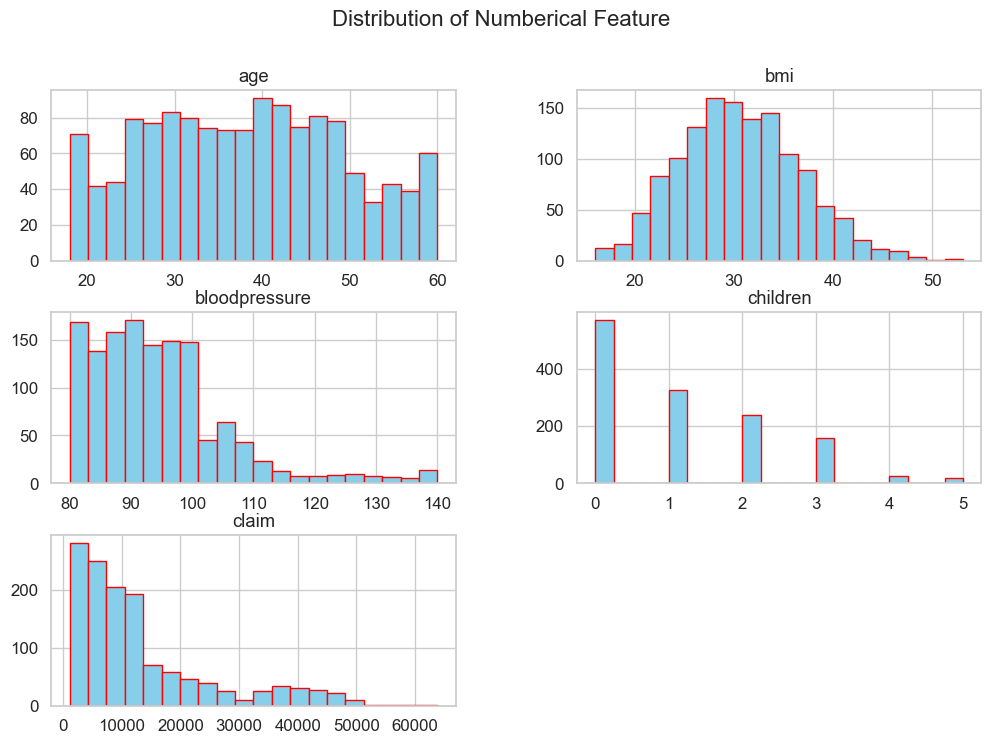

In [27]:
numeric_cols = ["age", "bmi", "bloodpressure", "children", "claim"]

df[numeric_cols].hist(bins=20, figsize=(12,8), color="skyblue", edgecolor="red")
plt.suptitle("Distribution of Numberical Feature", fontsize=16)
plt.show()

để vẽ biểu đồ phân phối (histogram) cho các cột dữ liệu dạng số trong bảng df, giúp bạn nhìn nhanh hình dạng phân bố của từng biến.

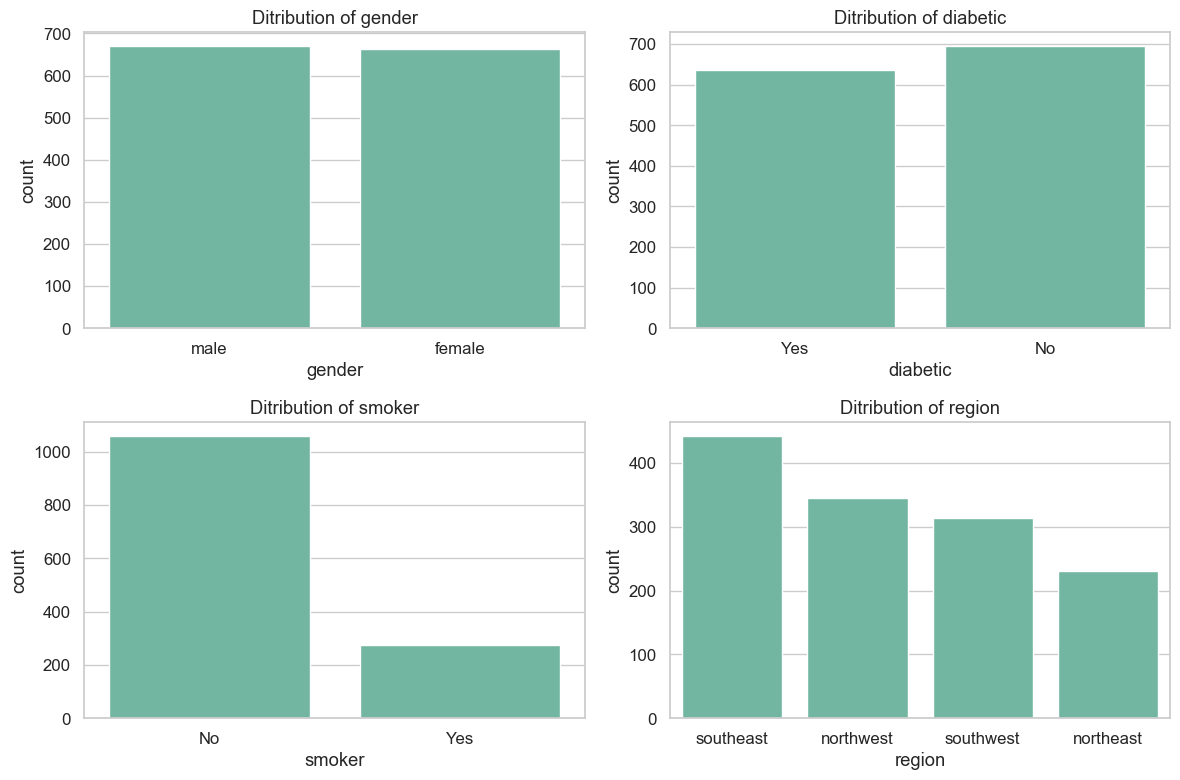

In [28]:
cat_cols = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x=col)
    plt.title(f"Ditribution of {col}")

plt.tight_layout()
plt.show()    

để vẽ biểu đồ cột đếm tần suất (Countplot) cho các cột dữ liệu dạng phân loại (categorical columns), giúp bạn nhanh chóng nhìn thấy sự phân bố số lượng của từng nhóm trong các biến chữ (như giới tính, tình trạng tiểu đường, hút thuốc, khu vực).

In [30]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

dùng để tính chi phí bảo hiểm trung bình (mean của cột claim) theo từng nhóm kết hợp giữa giới tính (gender) và tình trạng hút thuốc (smoker), sau đó làm tròn kết quả đến 2 chữ số thập phân.

Text(0.5, 1.0, 'Average Insurance Claim by Gender & smoking Status')

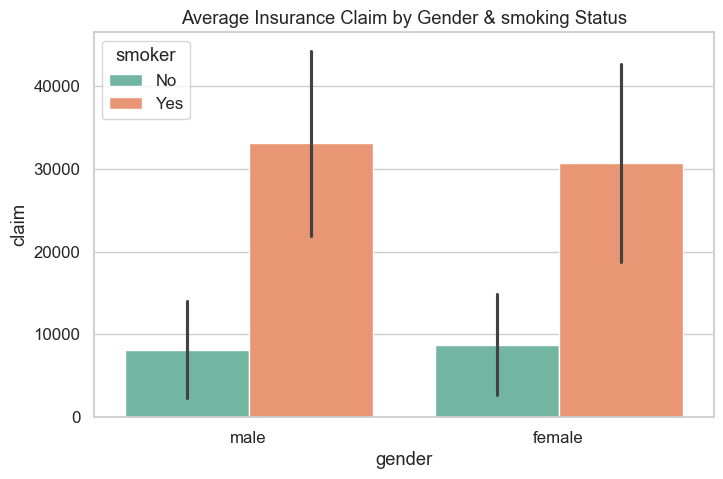

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator="mean", errorbar="sd")
plt.title("Average Insurance Claim by Gender & smoking Status")

In [32]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()

dùng để tính chi phí bảo hiểm trung bình theo từng khu vực và tình trạng tiểu đường, sau đó chuyển kết quả từ dạng bảng dọc (stacked) sang bảng ma trận ngang (pivot table) để dễ dàng so sánh.

In [33]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


Text(0, 0.5, 'Mean Claim')

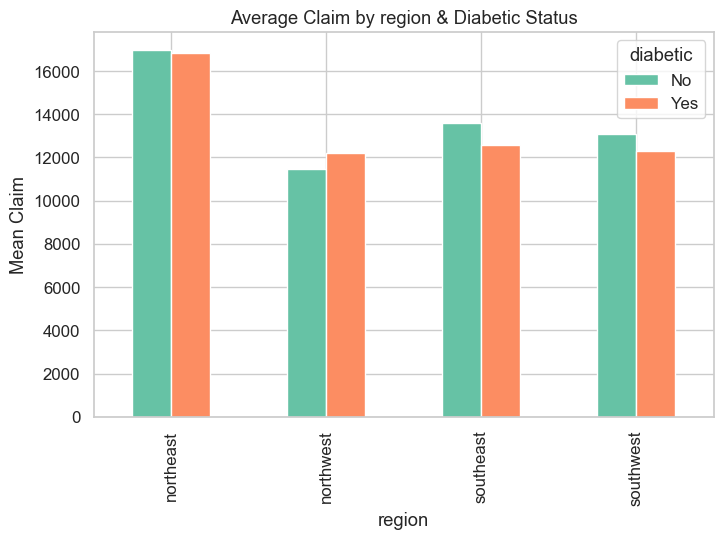

In [34]:
pivot_region_diabetic.plot(kind="bar", figsize=(8,5))
plt.title("Average Claim by region & Diabetic Status")
plt.ylabel("Mean Claim")

In [35]:
pivot_table = pd.pivot_table(df, values="claim", index="region", columns="smoker", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


để tạo một bảng tổng hợp (Pivot Table) 2 chiều, giúp bạn tính toán và quan sát mối quan hệ giữa khu vực sống (region), tình trạng hút thuốc (smoker) và chi phí bảo hiểm trung bình (claim).

In [36]:
pivot_table = pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


để tạo bảng tổng hợp 2 chiều, nhưng thay đổi góc nhìn sang mối quan hệ giữa số lượng con (children), tình trạng tiểu đường (diabetic) và chi phí bảo hiểm trung bình (claim).

In [37]:
numeric_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

Text(0.5, 1.0, 'Correlation Heatmap')

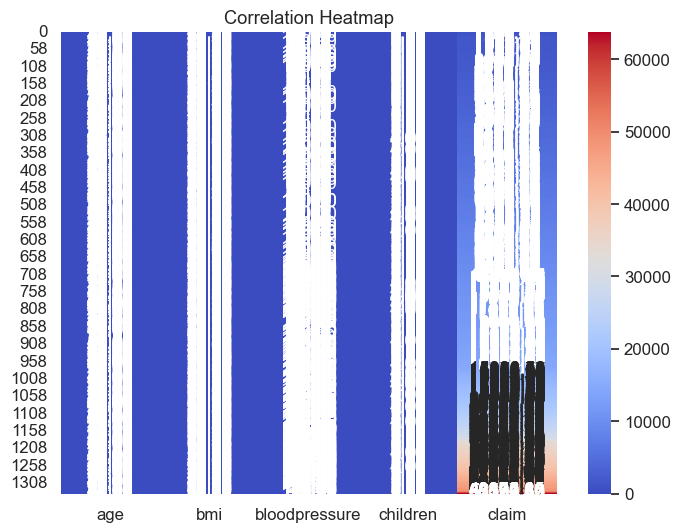

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

In [40]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


Text(0.5, 1.0, 'Correlation Heatmap')

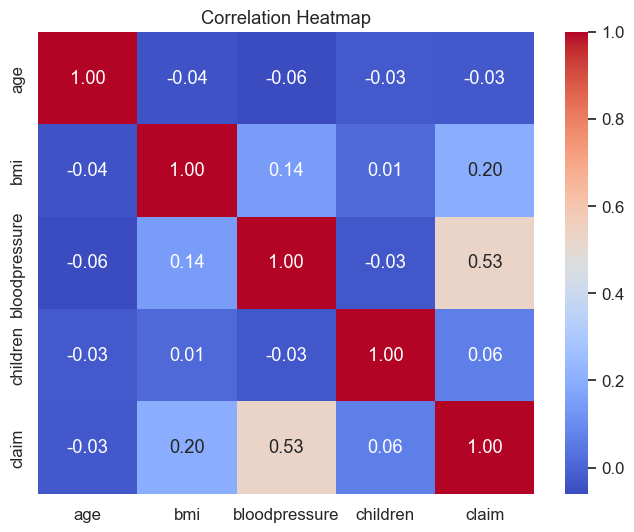

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

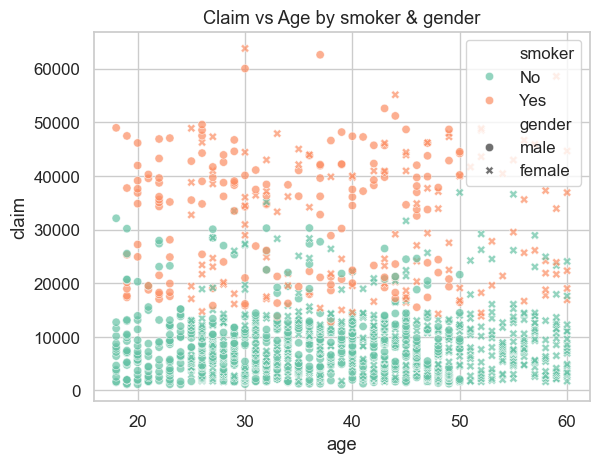

In [41]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.7)
plt.title("Claim vs Age by smoker & gender")
plt.show()

Text(0.5, 1.0, 'Relationship between BMI and Claim amound')

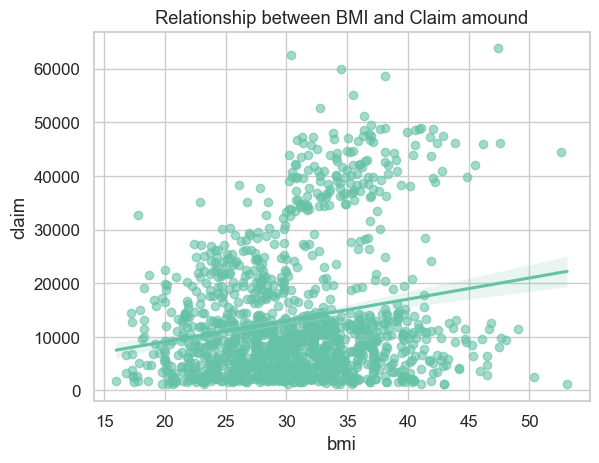

In [44]:
sns.regplot(data=df, x="bmi", y="claim", scatter_kws={"alpha": 0.6})
plt.title("Relationship between BMI and Claim amound")

tham số alpha=0.6 làm cho các chấm mờ đi một chút (độ trong suốt bằng 60%). Điều này cực kỳ hữu ích khi tập dữ liệu có nhiều điểm bị chồng đè lên nhau, giúp bạn thấy rõ vùng nào dữ liệu tập trung dày đặc.

Đặc điểm của regplot: Ngoài việc chấm các điểm dữ liệu thực tế, nó tự động tính toán và vẽ thêm một đường thẳng hồi quy tuyến tính (regression line) kèm theo dải mờ thể hiện khoảng tin cậy (confidence interval). Đường này cho thấy xu hướng chung: liệu chỉ số BMI tăng thì chi phí bảo hiểm có tăng theo hay không.

Seaborn để vẽ biểu đồ tương quan (Scatter Plot kết hợp đường hồi quy Regression Line) giữa chỉ số khối cơ thể (bmi) và chi phí bảo hiểm (claim).

Text(0.5, 1.0, 'Claim Distribution by Number of Children')

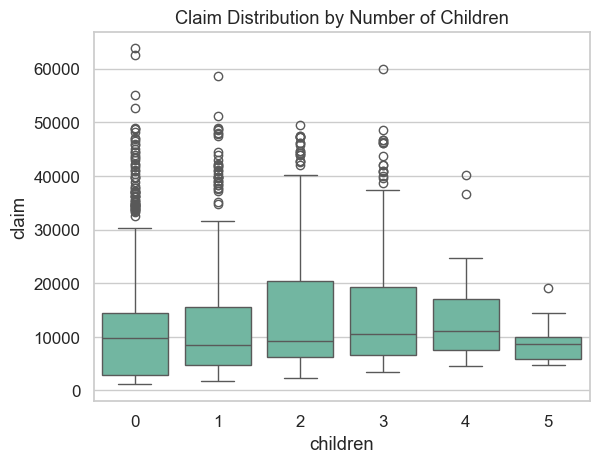

In [45]:
sns.boxplot(data=df, x="children", y="claim")
plt.title("Claim Distribution by Number of Children")

In [46]:
df["age_group"] = pd.cut(df["age"], bins = [0,18,30,45,60,100], labels=["<18", "18-30", "31-45", "46-60", "61-100"])


dùng để chia một cột dữ liệu liên tục (cột tuổi - age) thành các nhóm độ tuổi dạng phân loại (categorical) và tạo ra một cột mới tên là age_group trong bảng df.

In [47]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30


In [48]:
df["age_group"].value_counts()

age_group
31-45     553
46-60     383
18-30     380
<18        16
61-100      0
Name: count, dtype: int64

Text(0.5, 1.0, 'Average Claim by Age Group')

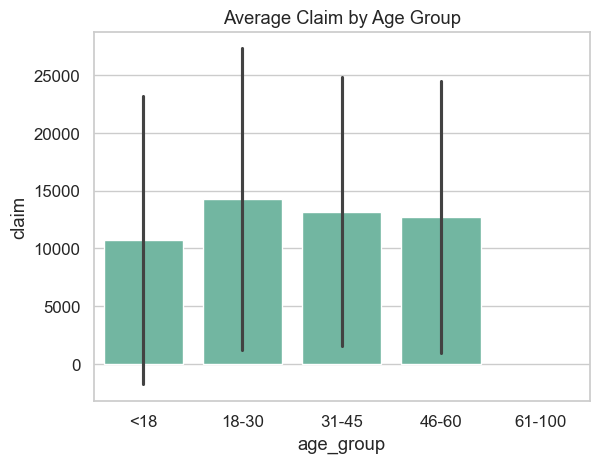

In [49]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd")
plt.title("Average Claim by Age Group")

In [50]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0,18.5,24.9,29.9, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])

có cấu trúc tương tự như lệnh phân loại độ tuổi phía trước, nhưng lần này dùng để phân loại chỉ số khối cơ thể (bmi) thành các nhóm thể trạng y tế chuẩn và lưu vào một cột mới tên là bmi_category.

In [51]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

In [53]:
import warnings
warnings.filterwarnings("ignore")

Text(0.5, 1.0, 'Claim Distribution by BMI Category & Smoking Status')

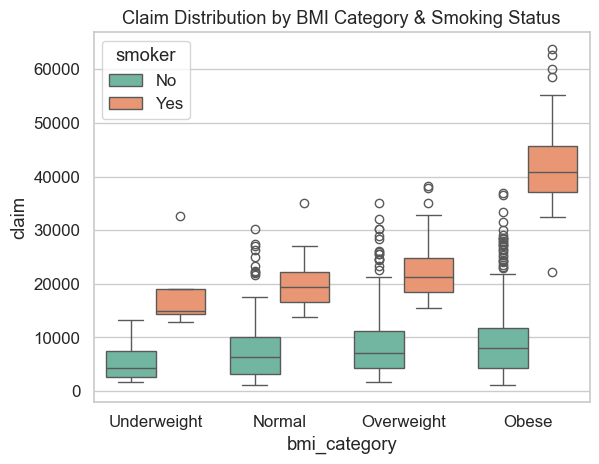

In [52]:
sns.boxplot(data=df, x="bmi_category", y="claim", hue="smoker")
plt.title("Claim Distribution by BMI Category & Smoking Status")

Seaborn để vẽ biểu đồ hộp (Boxplot) nhằm phân tích mối quan hệ đa chiều giữa thể trạng BMI (bmi_category), tình trạng hút thuốc (smoker), và chi phí bảo hiểm (claim).

Text(0.5, 1.0, 'Claim Distribution by BMI Category')

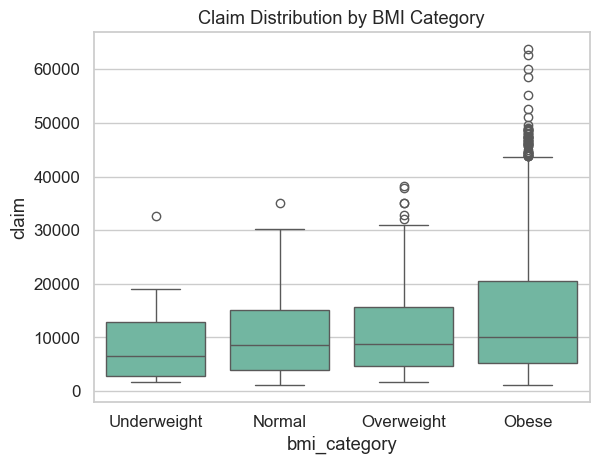

In [54]:
sns.boxplot(data=df, x="bmi_category", y="claim")
plt.title("Claim Distribution by BMI Category")

In [55]:
region_status = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean() *100),
    mean_claim = ("claim", "mean")
).reset_index()

groupby() kết hợp với agg() để tính toán đồng thời hai chỉ số quan trọng cho từng khu vực (region): tỷ lệ phần trăm người hút thuốc và chi phí bảo hiểm trung bình, sau đó chuyển kết quả thành một bảng dữ liệu phẳng (DataFrame).

In [56]:
region_status


,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


Text(0.5, 1.0, 'Smoker Rate and Average claim by region')

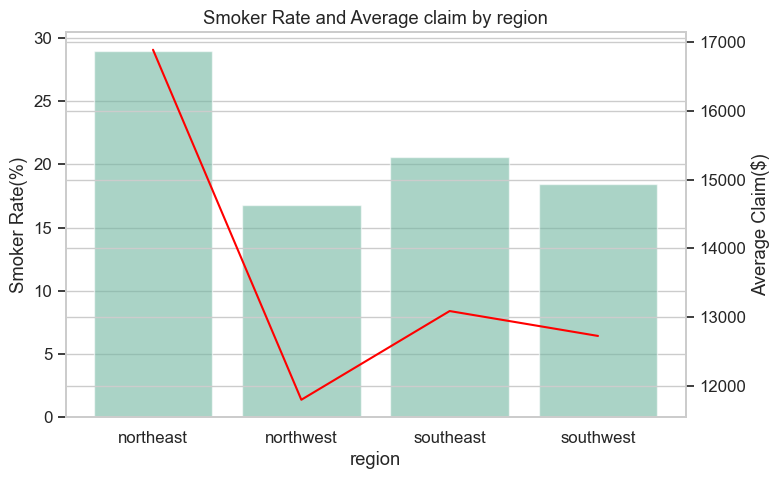

In [59]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data=region_status, x="region", y="smoker_rate", ax=ax1, alpha=0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_status, x="region", y="mean_claim", ax=ax2, color="red", markers="o")

ax1.set_ylabel("Smoker Rate(%)")
ax2.set_ylabel("Average Claim($)")
plt.title("Smoker Rate and Average claim by region")

# --- Data Preprocessing

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

from sklearn.model_selection import train_test_split

train_test_split: Hàm dùng để chia tập dữ liệu thành 2 phần: Tập huấn luyện (Train) cho mô hình học và tập kiểm thử (Test) để đánh giá xem mô hình dự đoán tốt đến mức nào trên dữ liệu mới chưa từng thấy.

from sklearn.preprocessing import LabelEncoder, StandardScaler

LabelEncoder: Công cụ chuyên dùng để mã hóa các biến dạng chữ (categorical columns) như giới tính (gender), tình trạng hút thuốc (smoker), khu vực (region) thành các con số nguyên (ví dụ: 0, 1, 2) để các thuật toán máy học có thể hiểu và tính toán được.

StandardScaler: Công cụ chuyên dùng để chuẩn hóa dữ liệu số (numerical columns) về cùng một thang đo có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1 (phương pháp Standard Scaling). Điều này giúp các mô hình (như Linear Regression, SVR) không bị chệch hướng do các cột có đơn vị đo quá lớn (ví dụ: cột claim hàng nghìn đô so với cột children chỉ có vài con số).

In [61]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45,Normal
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30,Obese
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30,Obese
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30,Obese
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30,Obese


In [63]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [66]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [68]:
X.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No


In [69]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}

In [70]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoder_{col}.pkl")

hực hiện quá trình mã hóa (Encoding) toàn bộ các cột dạng chữ/phân loại sang dạng số, đồng thời lưu lại từng bộ mã hóa (LabelEncoder) vào các file riêng biệt bằng joblib.

le = LabelEncoder()

Khởi tạo một đối tượng mã hóa mới cho mỗi cột.

X[col] = le.fit_transform(X[col])

fit_transform(): Vừa học các giá trị độc đáo (unique values) có trong cột, vừa chuyển đổi trực tiếp các chữ cái (như "male" / "female", "yes" / "no") thành các con số nguyên (ví dụ: 0 và 1) ngay trên tập dữ liệu đặc trưng X.

label_encoders[col] = le

Lưu đối tượng le vừa học được vào một từ điển (dictionary) tên là label_encoders để quản lý gọn gàng trong bộ nhớ phiên làm việc hiện tại.

joblib.dump(le, f"label_encoder_{col}.pkl")

Đây là bước sống còn cho khâu triển khai (Inference)! Dùng thư viện joblib để xuất (dump) đối tượng mã hóa của từng cột ra một file .pkl riêng biệt (ví dụ: label_encoder_smoker.pkl, label_encoder_region.pkl).

Cụ thể, bên trong bộ LabelEncoder của cột smoker sẽ lưu giữ một cái "từ điển dịch thuật" (Mapping) cố định từ lúc huấn luyện mô hình. Bạn có thể hiểu nó giống như bảng tra cứu sau nằm ngầm trong bộ nhớ của đối tượng le:

Python


# Bản chất bên trong đối tượng le của cột smoker sau khi fit_transform:
{
    "no": 0,
    "yes": 1
}
Hoặc đối với cột region (có 4 vùng), nó sẽ lưu danh sách các nhãn theo đúng thứ tự bảng chữ cái hoặc thứ tự xuất hiện lúc fit:

Python


# Bản chất bên trong đối tượng le của cột region:
{
    "northeast": 0,
    "northwest": 1,
    "southeast": 2,
    "southwest": 3
}

Câu hỏi của bạn cực kỳ sắc bén! Thực ra, hoàn toàn có thể tự viết một hàm chuyển đổi thủ công (ví dụ dùng từ điển mapping kiểu {'yes': 1, 'no': 0}) nếu bài toán chỉ có vài giá trị đơn giản.

1. Gặp các cột có hàng chục hoặc hàng nghìn giá trị
Với cột smoker chỉ có 2 giá trị (yes/no) thì viết thủ công rất dễ.

Nhưng nếu gặp cột như region (có hàng chục tỉnh thành), hoặc cột Product Name / Customer ID có hàng nghìn giá trị khác nhau, việc ngồi viết tay từ điển chuyển đổi (if-else hoặc dict) là bất khả thi và cực kỳ mất thời gian. LabelEncoder sinh ra để tự động hóa toàn bộ việc quét, liệt kê và gán số cho hàng nghìn giá trị đó trong một nốt nhạc.

2. Tránh sai sót do con người (Human Error)
Giả sử lúc bạn viết code train, mô hình quy định "male" là 0, "female" là 1.

Vài ngày sau, khi viết code cho app Streamlit, vì quên mất, bạn lại tự viết thủ công ngược lại ("male" là 1, "female" là 0).

Kết quả là mô hình sẽ nhận dữ liệu bị lệch pha hoàn toàn, dự đoán sai bét nhè mà Python sẽ không báo lỗi đỏ, khiến bạn rất khó tìm ra nguyên nhân. File .pkl triệt tiêu hoàn toàn rủi ro này vì nó lưu chính xác "bản gốc" từ lúc train.

3. Không chỉ có LabelEncoder, còn có các bộ tiền xử lý phức tạp khác
Trong Machine Learning, ngoài mã hóa chữ sang số, bạn còn hay dùng các bộ biến đổi dữ liệu phức tạp khác như:

StandardScaler / MinMaxScaler: Dùng để chuẩn hóa các cột số về cùng một khoảng giá trị (ví dụ trung bình bằng 0, độ lệch chuẩn bằng 1). Để chuẩn hóa, thuật toán phải tính ra số trung bình (mean) và độ lệch chuẩn (std) của toàn bộ hàng nghìn dòng dữ liệu lúc train.

Bạn không thể nào tự "viết tay" con số trung bình cực kỳ lẻ (ví dụ mean = 39.214829...) vào app được. Bạn bắt buộc phải lưu đối tượng scaler đó vào file .pkl để app dùng đúng con số đó mà chuẩn hóa dữ liệu mới do người dùng nhập.

In [71]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [73]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()

In [74]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

thực hiện việc chuẩn hóa dữ liệu số (Numerical Scaling) cho tập huấn luyện (X_train) và tập kiểm thử (X_test) bằng thuật toán StandardScaler, đây là bước chuẩn bị cực kỳ quan trọng trước khi đưa dữ liệu vào các mô hình Machine Learning.

scaler = StandardScaler()Khởi tạo bộ chuẩn hóa StandardScaler.Bản chất toán học: Thuật toán này sẽ đưa mỗi cột về dạng có giá trị trung bình bằng 0 ($\text{mean} = 0$) và độ lệch chuẩn bằng 1 ($\text{std} = 1$) theo công thức chuẩn hóa z-score:

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])fit_transform() (chỉ dùng riêng cho tập Train):fit: Học và tính toán ra giá trị trung bình ($\mu$) và độ lệch chuẩn ($\sigma$) của từng cột chỉ dựa trên dữ liệu của tập Train.transform: Áp dụng công thức để biến đổi các giá trị thô trên tập Train thành các giá trị đã được chuẩn hóa.

X_test[num_cols] = scaler.transform(X_test[num_cols])transform (dùng cho tập Test):Lưu ý quan trọng: Tuyệt đối không dùng fit_transform hay fit lại trên tập Test.Nó bắt buộc phải dùng chính xác các chỉ số ($\mu$ và $\sigma$) đã được học từ tập Train để biến đổi tập Test. Điều này đảm bảo tính khách quan (tránh hiện tượng rò rỉ dữ liệu - data leakage) và mô hình đánh giá trên tập Test mới phản ánh đúng thực tế khi đưa ra ngoài đời thực.


In [75]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [76]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [77]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


# --- trainning

In [80]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

Nhóm các mô hình Machine Learning (sklearn và xgboost):

LinearRegression: Mô hình Hồi quy tuyến tính truyền thống (dùng làm baseline để so sánh).

PolynomialFeatures: Công cụ tạo các đặc trưng đa thức (giúp mô hình tuyến tính học được các mối quan hệ phi tuyến tính phức tạp hơn).

RandomForestRegressor: Mô hình Ensemble dựa trên tập hợp nhiều cây quyết định (Random Forest), nổi tiếng với độ ổn định cao và ít bị overfitting.

SVR (Support Vector Regressor): Mô hình Hồi quy Vector Hỗ trợ, rất mạnh trong việc tìm khoảng phân cách tối ưu cho dữ liệu có cấu trúc phức tạp.

XGBRegressor: Mô hình XGBoost (Extreme Gradient Boosting) - một trong những mô hình cây quyết định tăng cường cực kỳ mạnh mẽ và phổ biến nhất hiện nay, thường cho độ chính xác rất cao trong các bài toán bảng dữ liệu (tabular data) như dự báo chi phí y tế của bạn.



Nhóm công cụ tối ưu hóa và đánh giá (Model Selection & Metrics):GridSearchCV: Công cụ tự động quét qua một dải các tham số (Hyperparameters) để tìm ra tổ hợp thông số tối ưu nhất cho mô hình.cross_val_score: Kỹ thuật kiểm định chéo (Cross-Validation), giúp chia dữ liệu thành nhiều phần để đánh giá mô hình một cách khách quan, tránh việc mô hình bị học tủ (overfitting) trên một tập train cụ thể.mean_absolute_error (MAE): Sai số tuyệt đối trung bình (đo lường mức độ lệch trung bình tính bằng đơn vị tiền tệ thực tế so với dự đoán).mean_squared_error (MSE): Sai số bình phương trung bình (thường kết hợp căn bậc hai để thành RMSE, giúp phạt nặng các dự đoán lệch pha lớn).r2_score ($R^2$ Score): Hệ số xác định, đo lường xem mô hình giải thích được bao nhiêu phần trăm độ biến thiên của dữ liệu (điểm tối đa là 1.0).

In [81]:
def evaluate_model(model, X_tran, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        "R2": r2, "MAE": mae, "RMSE": rmse
    }

định nghĩa một hàm đánh giá hiệu năng tự động (evaluate_model), giúp bạn nhanh chóng đo lường mức độ chính xác của bất kỳ mô hình Machine Learning nào sau khi dự đoán trên tập kiểm thử (X_test).

In [82]:
results = {}

In [86]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Khởi tạo từ điển lưu kết quả (giả định hàm evaluate_model đã được định nghĩa trước đó)
results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print("Linear Regression model trained")

# 2. Polynomial Regression
best_poly_model = None
best_poly_score = -np.inf

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    # Đã sửa: gọi score trên mô hình poly_lr thay vì đối tượng poly
    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, best_poly_lr = best_poly_model

# Đã sửa lỗi cú pháp f-string trong khóa dictionary
results[f"Polynomial Regression (deg = {degree})"] = evaluate_model(
    best_poly_lr, 
    poly.transform(X_train), # Dùng transform cho X_train (tránh fit_transform lại ở đây)
    poly.transform(X_test), 
    y_train, 
    y_test
)

print("Polynomial Regression models are trained")

# 3. Random Forest
rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],     # Đã sửa: min_sample_split -> min_samples_split
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)
print("Random Forest training is completed, best parameters: ", rf_grid.best_params_)

# 4. Support Vector Regression (SVR)
svr = SVR()
svr_params = {
    "kernel": ["rbf", "poly", "linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]
}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test) # Đã sửa: SVE -> SVR
print("SVR training is completed, best parameters: ", svr_grid.best_params_)

# 5. XGBoost
xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)
print("XGBoost training is completed, best parameters: ", xgb_grid.best_params_)

Linear Regression model trained
Polynomial Regression models are trained
Random Forest training is completed, best parameters:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is completed, best parameters:  {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost training is completed, best parameters:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


Khởi tạo (results = {})

Tạo một từ điển rỗng để lưu trữ các chỉ số đánh giá (R2, MAE, RMSE) của từng mô hình, giúp bạn dễ dàng so sánh chúng ở cuối chương trình.

Linear Regression (Hồi quy tuyến tính)

Huấn luyện mô hình cơ bản nhất làm mốc so sánh (Baseline). Không dùng GridSearch vì mô hình này không có tham số siêu việt (hyperparameters) cần tinh chỉnh.

Polynomial Regression (Hồi quy đa thức)

Dùng vòng lặp kiểm tra bậc đa thức degree (bậc 2 và bậc 3) để giúp mô hình bắt các mối quan hệ cong/phi tuyến tính trong dữ liệu bảo hiểm.

Lưu lại mô hình đạt điểm số $R^2$ cao nhất trên tập test và chuẩn hóa lại qua poly.transform().

Random Forest (Rừng ngẫu nhiên)

Sử dụng GridSearchCV với kỹ thuật kiểm định chéo (cv=3, n_jobs=-1 để chạy song song tận dụng tối đa CPU) để quét tìm bộ thông số tối ưu (n_estimators, max_depth, min_samples_split, min_samples_leaf).

Support Vector Regression (SVR)

Tương tự, dùng GridSearchCV để dò tìm các tham số quan trọng của SVR như loại hàm nhân (kernel), hệ số phạt (C), sai số cho phép (epsilon) và bậc đa thức (degree).

XGBoost (Extreme Gradient Boosting)

Huấn luyện mô hình mạnh mẽ nhất thường dùng cho bảng dữ liệu dạng bảng (tabular data).

Tối ưu hóa các siêu tham số kinh điển của cây tăng cường gồm số lượng cây (n_estimators), độ sâu (max_depth), tốc độ học (learning_rate) và tỷ lệ mẫu dữ liệu lấy cho mỗi cây (subsample).

In [87]:
results

{'Linear Regression': {'R2': 0.7035314604652811,
  'MAE': 4901.431444726493,
  'RMSE': np.float64(6365.3398187505145)},
 'Polynomial Regression (deg = 2)': {'R2': 0.7919722622630089,
  'MAE': 4073.7028079939805,
  'RMSE': np.float64(5332.033998174352)},
 'Random Forest': {'R2': 0.8125564975587437,
  'MAE': 4033.326703853527,
  'RMSE': np.float64(5061.3629550575)},
 'SVR': {'R2': 0.5085493457071615,
  'MAE': 5540.514852027497,
  'RMSE': np.float64(8195.439443057943)},
 'XGBoost': {'R2': 0.824335843374642,
  'MAE': 3838.8333462078654,
  'RMSE': np.float64(4899.749353423929)}}

In [89]:
results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.82,3838.83,4899.75
Random Forest,0.81,4033.33,5061.36
Polynomial Regression (deg = 2),0.79,4073.70,5332.03
Linear Regression,0.70,4901.43,6365.34
SVR,0.51,5540.51,8195.44


In [90]:
best_rf

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [92]:
best_r2 = results_df["R2"].max()

In [93]:
top_model = results_df[results_df["R2"] == best_r2]

In [94]:
top_model

,R2,MAE,RMSE
XGBoost,0.82,3838.83,4899.75


In [95]:
best_model = models[top_model.index[0]]

In [96]:
best_model


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [97]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

Best model selected: XGBoost
